# **E-Commerce Data Analysis**

---



The objective of this project is to analyze e-commerce sales data to gain insights into customer behavior, sales trends, and overall business performance. The analysis helps identify profitable categories and brands, understand sales patterns over time, and support data-driven business decisions.

**Data Loading and Initial Overview**

In this section, the dataset is downloaded directly from Google Drive using the gdown library and loaded into a Pandas DataFrame. An initial exploration is performed to understand the structure of the dataset, including the number of rows and columns, data types, and a preview of the first few records. Summary statistics are generated to understand numerical distributions, while dataset information helps identify missing values and inconsistencies.

Purpose:

*   Understand dataset size and structure
*   Identify data types and potential quality issues
*   Get a high-level understanding of the data









In [28]:
import gdown

file_id = "1fbCVtM8KKpRgFxlASWnG0ERBXEIQIzHt"
url = f"https://drive.google.com/uc?id={file_id}"

output = "Online-eCommerce.csv"
gdown.download(url, output, quiet=False)

print("\nDownloaded file:", output)


Downloading...
From: https://drive.google.com/uc?id=1fbCVtM8KKpRgFxlASWnG0ERBXEIQIzHt
To: /content/Online-eCommerce.csv
100%|██████████| 566k/566k [00:00<00:00, 26.2MB/s]


Downloaded file: Online-eCommerce.csv


In [29]:
import pandas as pd

df = pd.read_csv("Online-eCommerce.csv", low_memory=False)
print(df.head())


   Order_Number State_Code   Customer_Name  Order_Date     Status  \
0      139374.0         AP     Adhir Samal  11/01/2020  Delivered   
1      139375.0         AP  Dannana Jhammi  11/01/2020  Delivered   
2      139376.0         AS     Vipin Kumar  11/01/2020  Delivered   
3      139377.0         BR   Ranjeet Kumar  11/01/2020  Delivered   
4      139378.0         CG   Sajal Singhal  11/01/2020      Order   

                    Product      Category     Brand    Cost    Sales  \
0                512 GB M.2           SSD   Samsung  6500.0   8450.0   
1      RYZEN 3rd gen. 3500            CPU     Intel  8500.0  11050.0   
2          2GB Graphic Card  Graphic Card    Nvidia  7000.0   9100.0   
3            16 GB DDR4 RAM           RAM     Hynix  6550.0   8515.0   
4  Standard ATX motherboard   MotherBoard  Gigabyte  7650.0   9945.0   

   Quantity  Total_Cost  Total_Sales Assigned Supervisor  
0       1.0      6500.0       8450.0         Ajay Sharma  
1       3.0     25500.0      33150

In [30]:
# Number of columns and rows
rows, cols = df.shape
print("Number of Rows:", rows)
print("Number of Columns:", cols)


Number of Rows: 5110
Number of Columns: 14


In [31]:
# column data types
df.dtypes


,0
Order_Number,float64
State_Code,object
Customer_Name,object
Order_Date,object
Status,object
Product,object
Category,object
Brand,object
Cost,float64
Sales,float64


In [32]:
# First rows
display(df.head(10))

# Detailed dataset info
df.info()

# Summary statistics (numeric only)
df.describe()

# Summary for all columns (numeric + categorical)
df.describe(include='all')


,Order_Number,State_Code,Customer_Name,Order_Date,Status,Product,Category,Brand,Cost,Sales,Quantity,Total_Cost,Total_Sales,Assigned Supervisor
0,139374.0,AP,Adhir Samal,11/01/2020,Delivered,512 GB M.2,SSD,Samsung,6500.0,8450.0,1.0,6500.0,8450.0,Ajay Sharma
1,139375.0,AP,Dannana Jhammi,11/01/2020,Delivered,RYZEN 3rd gen. 3500,CPU,Intel,8500.0,11050.0,3.0,25500.0,33150.0,Roshan Kumar
2,139376.0,AS,Vipin Kumar,11/01/2020,Delivered,2GB Graphic Card,Graphic Card,Nvidia,7000.0,9100.0,2.0,14000.0,18200.0,Aarvi Gupta
3,139377.0,BR,Ranjeet Kumar,11/01/2020,Delivered,16 GB DDR4 RAM,RAM,Hynix,6550.0,8515.0,3.0,19650.0,25545.0,Vijay Singh
4,139378.0,CG,Sajal Singhal,11/01/2020,Order,Standard ATX motherboard,MotherBoard,Gigabyte,7650.0,9945.0,4.0,30600.0,39780.0,Aadil Khan
5,139379.0,CG,Akhilesh Kumar,11/01/2020,Order,Compact with 1 Fan,Cabinet,Asus,1150.0,1495.0,2.0,2300.0,2990.0,Advika Joshi
6,139380.0,CG,Suvankar Chakraborty,11/01/2020,Order,USB Backlight Keyboard,Keyboard,Dell,850.0,1105.0,3.0,2550.0,3315.0,Ajay Sharma
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,139381.0,CG,Suvankar Adhikary,12/01/2020,Order,Ergonomic Mouse,Mouse,Samsung,650.0,845.0,2.0,1300.0,1690.0,Ajay Sharma


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order_Number         5095 non-null   float64
 1   State_Code           5095 non-null   object 
 2   Customer_Name        5095 non-null   object 
 3   Order_Date           5095 non-null   object 
 4   Status               5095 non-null   object 
 5   Product              5095 non-null   object 
 6   Category             5095 non-null   object 
 7   Brand                5095 non-null   object 
 8   Cost                 5095 non-null   float64
 9   Sales                5095 non-null   float64
 10  Quantity             5095 non-null   float64
 11  Total_Cost           5095 non-null   float64
 12  Total_Sales          5095 non-null   float64
 13  Assigned Supervisor  5095 non-null   object 
dtypes: float64(6), object(8)
memory usage: 559.0+ KB


,Order_Number,State_Code,Customer_Name,Order_Date,Status,Product,Category,Brand,Cost,Sales,Quantity,Total_Cost,Total_Sales,Assigned Supervisor
count,5095.000000,5095,5095,5095,5095,5095,5095,5095,5095.000000,5095.000000,5095.000000,5095.000000,5095.000000,5095
unique,NaN,35,56,1086,4,1228,14,11,NaN,NaN,NaN,NaN,NaN,6
top,NaN,MH,Adhir Samal,03/04/2022,Processing,2GB Graphic Card,Monitor,Samsung,NaN,NaN,NaN,NaN,NaN,Aarvi Gupta
freq,NaN,904,122,181,1278,300,749,1199,NaN,NaN,NaN,NaN,NaN,967
mean,141921.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6066.123651,7885.960746,2.486948,14991.778214,19489.311678,NaN
std,1470.944141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3952.022039,5137.628651,1.113581,12574.918427,16347.393955,NaN
min,139374.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,350.000000,455.000000,1.000000,350.000000,455.000000,NaN
25%,140647.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2100.000000,2730.000000,2.000000,4500.000000,5850.000000,NaN
50%,141921.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6550.000000,8515.000000,2.000000,10720.000000,13936.000000,NaN
75%,143194.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8500.000000,11050.000000,3.000000,22950.000000,29835.000000,NaN


**Data Pre-processing**

Data pre-processing focuses on cleaning and preparing the dataset for analysis. Missing values are identified and handled appropriately numerical columns are filled with median values, while categorical columns are filled with mode values. Duplicate records are removed to avoid biased analysis. Data types are corrected for categorical fields, and new derived columns such as Profit and Profit Margin are created. Date fields are cleaned, converted into proper datetime format, and additional time-based features are extracted.

Purpose:

*   Improve data quality and consistency
*  Handle missing and duplicate records
*   Create meaningful derived features for analysis


In [33]:
# Missing values count & percent
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct.round(2)
})

missing_df.sort_values("Missing Count", ascending=False)


,Missing Count,Missing %
Order_Number,15,0.29
State_Code,15,0.29
Customer_Name,15,0.29
Order_Date,15,0.29
Status,15,0.29
Product,15,0.29
Category,15,0.29
Brand,15,0.29
Cost,15,0.29
Sales,15,0.29


In [34]:
# Handling Missing Values
# Fill missing numeric values with median
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill missing text/categorical with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Removing Duplicates
# Count duplicates
print("Duplicate Rows:", df.duplicated().sum())

# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)

print("After removing duplicates:", df.shape)

print(df)

Duplicate Rows: 14
After removing duplicates: (5096, 14)
      Order_Number State_Code          Customer_Name  Order_Date      Status  \
0         139374.0         AP            Adhir Samal  11/01/2020   Delivered   
1         139375.0         AP         Dannana Jhammi  11/01/2020   Delivered   
2         139376.0         AS            Vipin Kumar  11/01/2020   Delivered   
3         139377.0         BR          Ranjeet Kumar  11/01/2020   Delivered   
4         139378.0         CG          Sajal Singhal  11/01/2020       Order   
...            ...        ...                    ...         ...         ...   
5091      144464.0         TN  Rahul Kumar Prajapati  31/12/2022   Delivered   
5092      144465.0         TR             Sagar Jeur  31/12/2022     Shipped   
5093      144466.0         UK        Rhushikesh Mane  31/12/2022       Order   
5094      144467.0         UP           Ashish Kumar  31/12/2022  Processing   
5095      144468.0         WB           Javed Akhter  31/12/202

In [35]:
# Correcting Data Types
cat_cols = ['State_Code', 'Category', 'Brand', 'Status']

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

print(df)

      Order_Number State_Code          Customer_Name  Order_Date      Status  \
0         139374.0         AP            Adhir Samal  11/01/2020   Delivered   
1         139375.0         AP         Dannana Jhammi  11/01/2020   Delivered   
2         139376.0         AS            Vipin Kumar  11/01/2020   Delivered   
3         139377.0         BR          Ranjeet Kumar  11/01/2020   Delivered   
4         139378.0         CG          Sajal Singhal  11/01/2020       Order   
...            ...        ...                    ...         ...         ...   
5091      144464.0         TN  Rahul Kumar Prajapati  31/12/2022   Delivered   
5092      144465.0         TR             Sagar Jeur  31/12/2022     Shipped   
5093      144466.0         UK        Rhushikesh Mane  31/12/2022       Order   
5094      144467.0         UP           Ashish Kumar  31/12/2022  Processing   
5095      144468.0         WB           Javed Akhter  31/12/2022   Delivered   

                       Product      Cat

Additional useful columns are created to enhance analysis. These include profit-related metrics and date-based features such as year, month, day, and year-month. These derived features allow deeper time-series and performance analysis across different periods.

Purpose:

*   Enable time-based trend analysis
*   Improve analytical depth
*   Support aggregation and comparison









In [36]:
# Creating derived columns
# Profit
if all(c in df.columns for c in ['Total_Sales', 'Total_Cost']):
    df['Profit'] = df['Total_Sales'] - df['Total_Cost']

# Profit Margin
if 'Profit' in df.columns and 'Total_Sales' in df.columns:
    df['Profit_Margin'] = (df['Profit'] / df['Total_Sales']).round(2)

print(df)


      Order_Number State_Code          Customer_Name  Order_Date      Status  \
0         139374.0         AP            Adhir Samal  11/01/2020   Delivered   
1         139375.0         AP         Dannana Jhammi  11/01/2020   Delivered   
2         139376.0         AS            Vipin Kumar  11/01/2020   Delivered   
3         139377.0         BR          Ranjeet Kumar  11/01/2020   Delivered   
4         139378.0         CG          Sajal Singhal  11/01/2020       Order   
...            ...        ...                    ...         ...         ...   
5091      144464.0         TN  Rahul Kumar Prajapati  31/12/2022   Delivered   
5092      144465.0         TR             Sagar Jeur  31/12/2022     Shipped   
5093      144466.0         UK        Rhushikesh Mane  31/12/2022       Order   
5094      144467.0         UP           Ashish Kumar  31/12/2022  Processing   
5095      144468.0         WB           Javed Akhter  31/12/2022   Delivered   

                       Product      Cat

In [37]:
# Date Correction
df['Order_Date'] = df['Order_Date'].astype(str).str.strip()

# Auto parse dates
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

mask_na = df['Order_Date'].isna()
if mask_na.sum() > 0:
    df.loc[mask_na, 'Order_Date'] = pd.to_datetime(
        df.loc[mask_na, 'Order_Date'],
        errors='coerce',
        dayfirst=True
    )

print("\nAfter correction:")
print(df['Order_Date'].head(20))
print(df['Order_Date'].isna().sum(), "dates could not be converted.")

# Create useful derived date columns
df['Order_Year'] = df['Order_Date'].dt.year
df['Order_Month'] = df['Order_Date'].dt.month
df['Order_Day'] = df['Order_Date'].dt.day
df['Order_Month_Name'] = df['Order_Date'].dt.strftime('%B')
df['Year_Month'] = df['Order_Date'].dt.to_period('M').astype(str)
df = df.dropna(subset=['Order_Date']).reset_index(drop=True)

print("\nDate correction completed successfully!")




After correction:
0    2020-11-01
1    2020-11-01
2    2020-11-01
3    2020-11-01
4    2020-11-01
5    2020-11-01
6    2020-11-01
7    2020-03-04
8    2020-12-01
9           NaT
10          NaT
11          NaT
12          NaT
13          NaT
14          NaT
15          NaT
16          NaT
17          NaT
18          NaT
19          NaT
Name: Order_Date, dtype: datetime64[ns]
3056 dates could not be converted.

Date correction completed successfully!


In [38]:
print(df)

      Order_Number State_Code        Customer_Name Order_Date      Status  \
0         139374.0         AP          Adhir Samal 2020-11-01   Delivered   
1         139375.0         AP       Dannana Jhammi 2020-11-01   Delivered   
2         139376.0         AS          Vipin Kumar 2020-11-01   Delivered   
3         139377.0         BR        Ranjeet Kumar 2020-11-01   Delivered   
4         139378.0         CG        Sajal Singhal 2020-11-01       Order   
...            ...        ...                  ...        ...         ...   
2035      144321.0         TN   Aniruddha Kekapure 2022-10-12     Shipped   
2036      144322.0         TR           Aslam Raza 2022-10-12       Order   
2037      144323.0         MH        Roshan Zameer 2022-10-12  Processing   
2038      144324.0         CH  Rakesh Kumar Sharma 2022-11-12   Delivered   
2039      144325.0         DH     Shivanand Sahani 2022-12-12     Shipped   

                         Product      Category     Brand     Cost    Sales 

Specific subsets of data are filtered, such as high-sales orders, loss-making orders, and category-specific orders. Aggregation techniques like group-by operations are applied to compute total sales by category, total profit by brand, and average quantity sold per state.

Purpose:

*   Identify high-performing and loss-making segments
*   Summarize data for business insights
*  Enable comparative analysis











In [39]:
# Filtering
high_sales = df[df['Total_Sales'] > 10000]
loss_orders = df[df['Profit'] < 0]
electronics_orders = df[df['Category'] == 'Electronics']

print("High Sales:\n", high_sales.head())
print("\nLoss Orders:\n", loss_orders.head())
print("\nElectronics Orders:\n", electronics_orders.head())




High Sales:
    Order_Number State_Code   Customer_Name Order_Date      Status  \
1      139375.0         AP  Dannana Jhammi 2020-11-01   Delivered   
2      139376.0         AS     Vipin Kumar 2020-11-01   Delivered   
3      139377.0         BR   Ranjeet Kumar 2020-11-01   Delivered   
4      139378.0         CG   Sajal Singhal 2020-11-01       Order   
7      141921.0         MH     Adhir Samal 2020-03-04  Processing   

                    Product      Category     Brand    Cost    Sales  ...  \
1      RYZEN 3rd gen. 3500            CPU     Intel  8500.0  11050.0  ...   
2          2GB Graphic Card  Graphic Card    Nvidia  7000.0   9100.0  ...   
3            16 GB DDR4 RAM           RAM     Hynix  6550.0   8515.0  ...   
4  Standard ATX motherboard   MotherBoard  Gigabyte  7650.0   9945.0  ...   
7          2GB Graphic Card       Monitor   Samsung  6550.0   8515.0  ...   

   Total_Cost  Total_Sales  Assigned Supervisor  Profit  Profit_Margin  \
1     25500.0      33150.0         

In [40]:
#  Aggregation
sales_by_category = df.groupby("Category", observed=False)['Total_Sales'].sum()
profit_by_brand = df.groupby("Brand", observed=False)['Profit'].sum()
avg_qty_by_state = df.groupby("State_Code", observed=False)['Quantity'].mean()

print("\nSales by Category:\n", sales_by_category)
print("\nProfit by Brand:\n", profit_by_brand)
print("\nAvg Quantity per State:\n", avg_qty_by_state)



Sales by Category:
 Category
CPU              7333950.0
Cabinet          1186770.0
Computer Case     828724.0
Graphic Card     5038150.0
HDD              4978350.0
Keyboard          535145.0
Monitor          9259016.0
MotherBoard        39780.0
Motherboard      1252953.0
Mouse            1618370.0
NIC               591994.0
Printer          1109667.0
RAM              1263457.0
SSD              4050800.0
Name: Total_Sales, dtype: float64

Profit by Brand:
 Brand
Acer                591105.0
Asus                273870.0
Dell               1341645.0
Gigabyte            550530.0
Hynix               503355.0
Intel              1692450.0
MSI                 304110.0
Nvidia             1162650.0
Samsung            1451541.0
Seagate             411000.0
Western Digital     737850.0
Name: Profit, dtype: float64

Avg Quantity per State:
 State_Code
AN    2.666667
AP    2.131579
AR    2.324324
AS    2.472222
BR    2.506579
CG    2.472222
CH    2.583333
DD    2.468750
DH    2.484848
DL    2.46969

**Exploratory Data Analysis (EDA)**


EDA is performed to visually and statistically explore the data. Univariate analysis examines the distribution of numerical and categorical variables. Bivariate analysis explores relationships between key metrics such as sales, profit, and quantity. Multivariate analysis uses pivot tables and heatmaps to study interactions between multiple variables, including category, brand, and time.

Purpose:

*  Discover patterns and trends
*  Identify relationships between variables
*   Detect outliers and anomalies







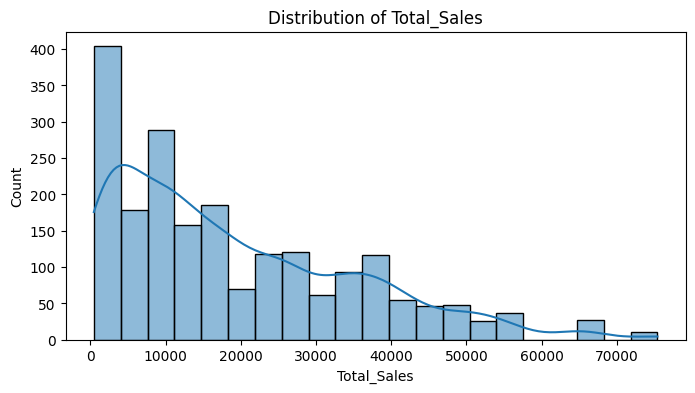

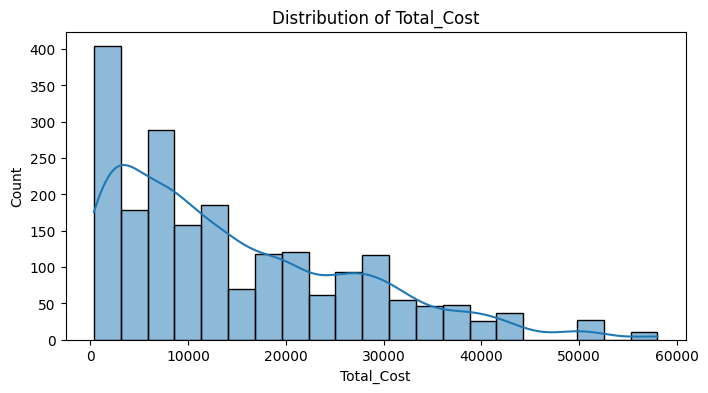

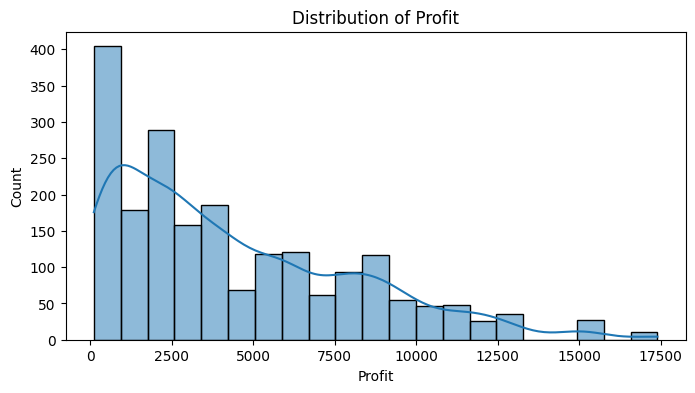

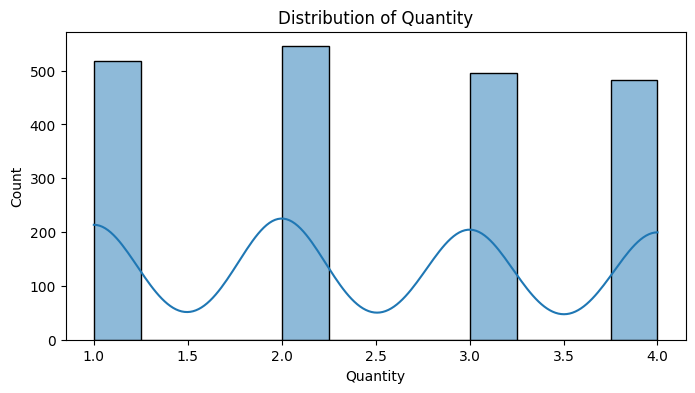

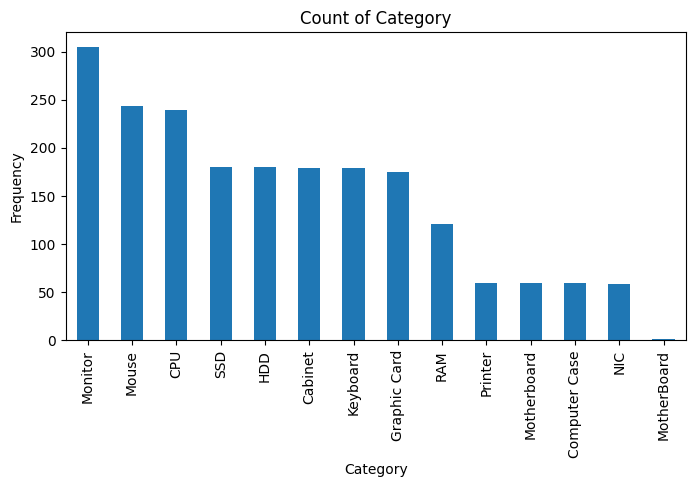

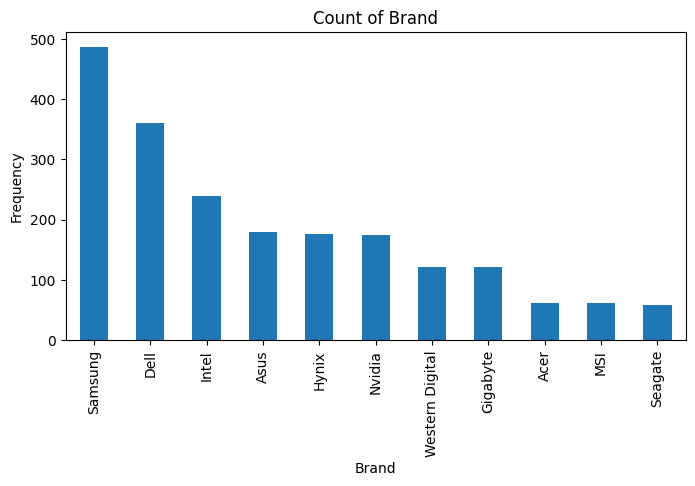

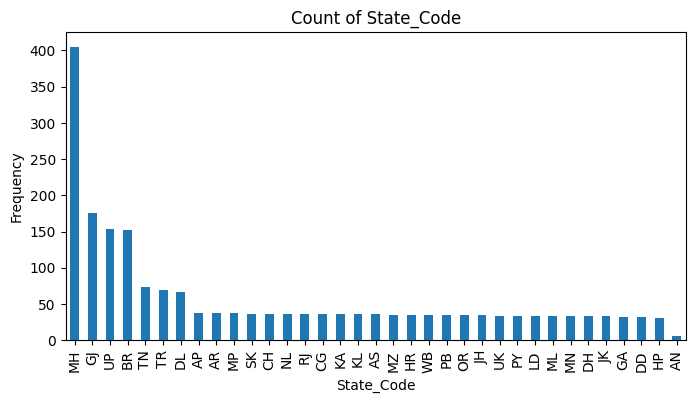

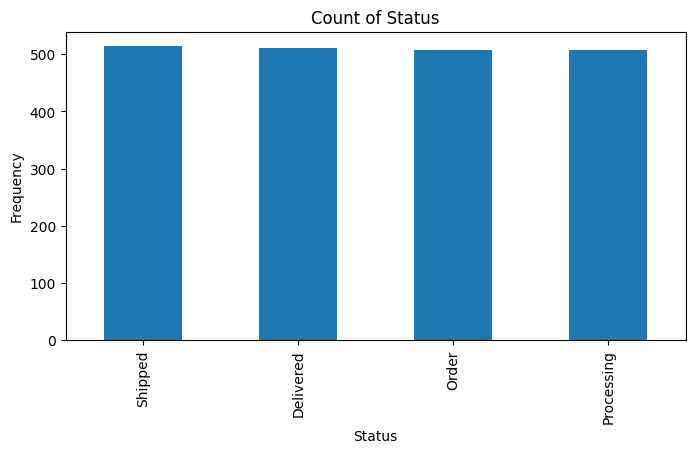

In [41]:
# Univariate Analysis
# Numerical Columns Distribution
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Total_Sales', 'Total_Cost', 'Profit', 'Quantity']

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# Categorical Columns Count
cat_cols = ['Category', 'Brand', 'State_Code', 'Status']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


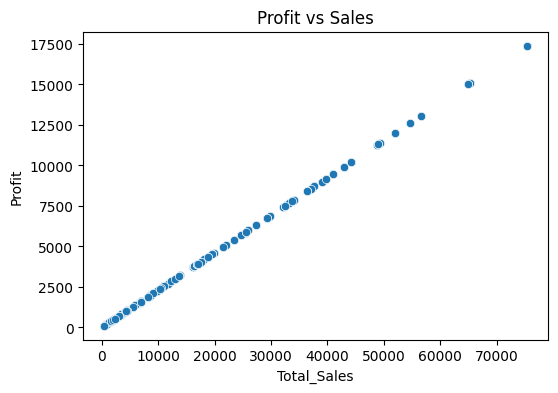

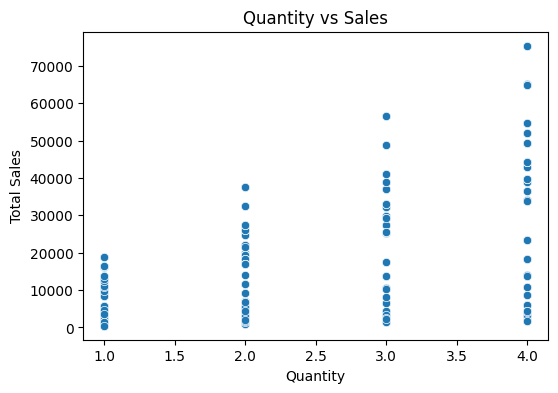

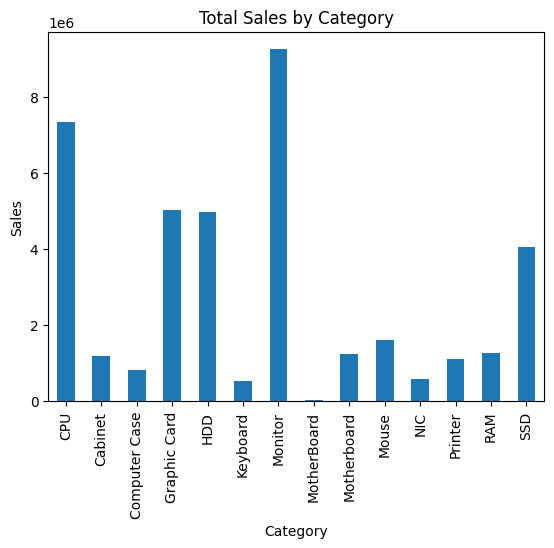

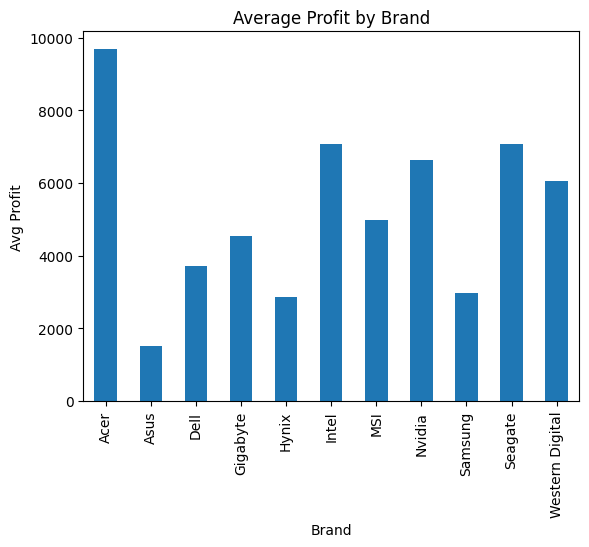

In [42]:
# Bivariate Analysis
# Sales vs Profit
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Total_Sales', y='Profit')
plt.title("Profit vs Sales")
plt.show()


# Quantity vs Sales
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Quantity'], y=df['Total_Sales'])
plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.show()

# Category vs Total Sales
df.groupby("Category", observed=False)['Total_Sales'].sum().plot(kind='bar')
plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.show()

# Brand vs Average Profit
df.groupby("Brand", observed=False)['Profit'].mean().plot(kind='bar')
plt.title("Average Profit by Brand")
plt.ylabel("Avg Profit")
plt.show()


In [43]:
# Multivariate analysis
# Category + Brand + Sales
pivot_cat_brand = df.pivot_table(
    values='Total_Sales',
    index='Category',
    columns='Brand',
    aggfunc='sum',
    fill_value=0,
    observed=False
)

pivot_cat_brand



Brand,Acer,Asus,Dell,Gigabyte,Hynix,Intel,MSI,Nvidia,Samsung,Seagate,Western Digital
Category,,,,,,,,,,,
CPU,0.0,0.0,0.0,0.0,0.0,7333950.0,0.0,0.0,0.0,0.0,0.0
Cabinet,0.0,1186770.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Computer Case,0.0,0.0,0.0,0.0,828724.0,0.0,0.0,0.0,0.0,0.0,0.0
Graphic Card,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5038150.0,0.0,0.0,0.0
HDD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1781000.0,3197350.0
Keyboard,0.0,0.0,535145.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Monitor,2561455.0,0.0,5278650.0,0.0,0.0,0.0,0.0,0.0,1418911.0,0.0,0.0
MotherBoard,0.0,0.0,0.0,39780.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Motherboard,0.0,0.0,0.0,793845.0,0.0,0.0,459108.0,0.0,0.0,0.0,0.0


**Sales Trend Analysis**

Monthly sales trends are analyzed using time-series plots. This helps identify seasonal patterns, growth trends, and fluctuations in sales performance over time.

Purpose:

* Understand business seasonality
*   Track sales performance over time
*   Support forecasting and planning









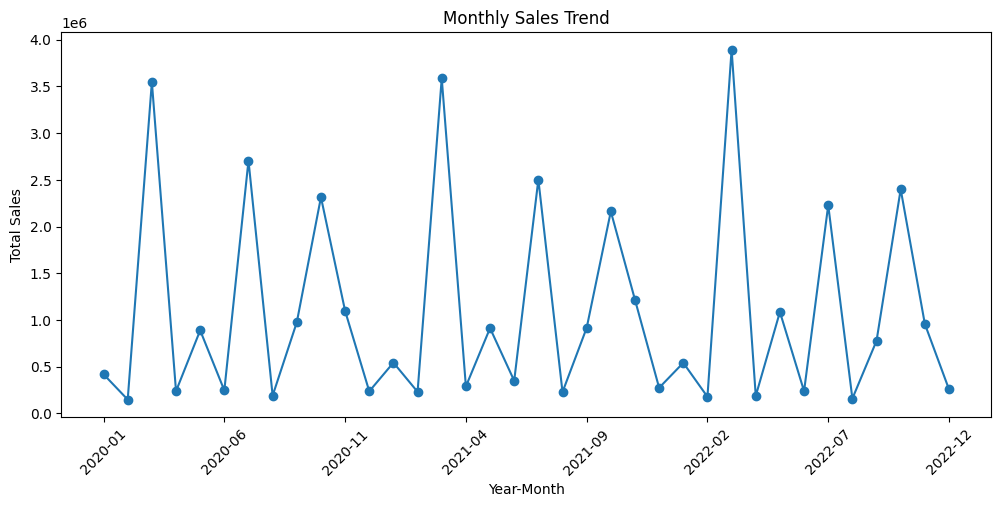

In [44]:
# Monthly Sales Trend
monthly_sales = df.groupby("Year_Month")['Total_Sales'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

**Correlation Analysis**

A correlation matrix and heatmap are used to measure the strength and direction of relationships between numerical variables such as total sales, cost, profit, and quantity. This helps understand how key metrics influence each other.

Purpose:

*   Identify strongly related variables
*   Support pricing and cost optimization decisions
*   Improve business strategy










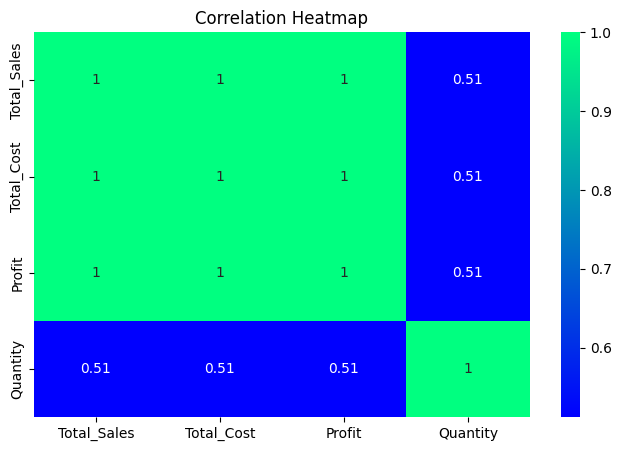

In [45]:
# Correlation Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df[['Total_Sales','Total_Cost','Profit','Quantity']].corr(), annot=True, cmap='winter')
plt.title("Correlation Heatmap")
plt.show()


**GroupBy Analysis**

GroupBy analysis is used to summarize and analyze the dataset by grouping data based on key categorical variables such as Category, Brand, State, and Time. This helps in understanding performance patterns and identifying high- and low-performing business segments.

Purpose:

*   Identifies top-performing categories, brands, and regions
*   Highlights profitability drivers
*   Supports targeted marketing and inventory planning
*   Enables data-driven strategic decisions



In [46]:
# Groupby Analysis
# Total Sales by Category
sales_by_category = df.groupby("Category", observed=False)["Total_Sales"].sum().sort_values(ascending=False)
print("Total Sales by Category:\n", sales_by_category)

# Total Profit by Brand
profit_by_brand = df.groupby("Brand", observed=False)["Profit"].sum().sort_values(ascending=False)
print("\nTotal Profit by Brand:\n", profit_by_brand)

# Average Quantity Purchased per State
avg_quantity_state = df.groupby("State_Code", observed=False)["Quantity"].mean().sort_values(ascending=False)
print("\nAverage Quantity per State:\n", avg_quantity_state)

# Monthly Sales Trend
monthly_sales = df.groupby("Year_Month", observed=False)["Total_Sales"].sum()
print("\nMonthly Sales Trend:\n", monthly_sales)


Total Sales by Category:
 Category
Monitor          9259016.0
CPU              7333950.0
Graphic Card     5038150.0
HDD              4978350.0
SSD              4050800.0
Mouse            1618370.0
RAM              1263457.0
Motherboard      1252953.0
Cabinet          1186770.0
Printer          1109667.0
Computer Case     828724.0
NIC               591994.0
Keyboard          535145.0
MotherBoard        39780.0
Name: Total_Sales, dtype: float64

Total Profit by Brand:
 Brand
Intel              1692450.0
Samsung            1451541.0
Dell               1341645.0
Nvidia             1162650.0
Western Digital     737850.0
Acer                591105.0
Gigabyte            550530.0
Hynix               503355.0
Seagate             411000.0
MSI                 304110.0
Asus                273870.0
Name: Profit, dtype: float64

Average Quantity per State:
 State_Code
LD    2.941176
HP    2.866667
AN    2.666667
WB    2.657143
MP    2.648649
UP    2.647059
RJ    2.638889
MN    2.636364
CH    2.58333

**Pivot Table Analysis**

Pivot tables are created to analyze sales and profit across multiple dimensions such as category, brand, state, and month. This provides a multi-level view of performance and helps identify top-performing combinations.

Purpose:

*  Enable multi-dimensional analysis
*  Identify best-performing categories and brands
*  Support strategic decision-making







In [47]:
# Pivot Table Analysis
# Category vs Brand - Total Sales
pivot_cat_brand = df.pivot_table(
    values="Total_Sales",
    index="Category",
    columns="Brand",
    aggfunc="sum",
    fill_value=0,
    observed=False
)
print("\nPivot Table: Sales by Category & Brand:\n", pivot_cat_brand)



Pivot Table: Sales by Category & Brand:
 Brand               Acer       Asus       Dell  Gigabyte     Hynix      Intel  \
Category                                                                        
CPU                  0.0        0.0        0.0       0.0       0.0  7333950.0   
Cabinet              0.0  1186770.0        0.0       0.0       0.0        0.0   
Computer Case        0.0        0.0        0.0       0.0  828724.0        0.0   
Graphic Card         0.0        0.0        0.0       0.0       0.0        0.0   
HDD                  0.0        0.0        0.0       0.0       0.0        0.0   
Keyboard             0.0        0.0   535145.0       0.0       0.0        0.0   
Monitor        2561455.0        0.0  5278650.0       0.0       0.0        0.0   
MotherBoard          0.0        0.0        0.0   39780.0       0.0        0.0   
Motherboard          0.0        0.0        0.0  793845.0       0.0        0.0   
Mouse                0.0        0.0        0.0  918450.0       0.0 

In [48]:
# State vs Category — Average Profit
pivot_state_category_profit = df.pivot_table(
    values="Profit",
    index="State_Code",
    columns="Category",
    aggfunc="mean",
    fill_value=0,
    observed=False
)
print("\nPivot Table: Avg Profit by State & Category:\n", pivot_state_category_profit)



Pivot Table: Avg Profit by State & Category:
 Category             CPU      Cabinet  Computer Case  Graphic Card  \
State_Code                                                           
AN              0.000000     0.000000          0.000   8400.000000   
AP           6540.000000  1302.000000       2469.000   4200.000000   
AR           7860.000000   690.000000        504.000   9825.000000   
AS           3187.500000  1579.500000       3150.000   5250.000000   
BR           7591.666667  1745.500000       1708.000   6412.500000   
CG           6330.000000  1454.000000       3955.500   5850.000000   
CH           9600.000000   487.500000       5089.000   6720.000000   
DD           4250.000000  1608.750000       7860.000   6150.000000   
DH           7650.000000   861.000000       2973.000   4750.000000   
DL           5614.285714  1592.142857          0.000   5950.000000   
GA           5737.500000  1723.000000        504.000   7950.000000   
GJ           7564.285714  1689.937500      

In [49]:
# Monthly Sales by Category
pivot_month_category = df.pivot_table(
    values="Total_Sales",
    index="Year_Month",
    columns="Category",
    aggfunc="sum",
    fill_value=0,
    observed=False
)
print("\nPivot Table: Monthly Sales by Category:\n", pivot_month_category)


Pivot Table: Monthly Sales by Category:
 Category         CPU   Cabinet  Computer Case  Graphic Card       HDD  \
Year_Month                                                              
2020-01     160550.0       0.0        39195.0       27300.0       0.0   
2020-02      11050.0    4485.0            0.0       27300.0   46800.0   
2020-03     746850.0  117897.0        69329.0      464750.0  465400.0   
2020-04      88400.0       0.0            0.0           0.0   39000.0   
2020-05     111800.0   23621.0            0.0      128700.0  154050.0   
2020-06      44200.0   13936.0         9100.0           0.0   26000.0   
2020-07     646100.0   64675.0        52078.0      342550.0  263250.0   
2020-08      18850.0   21372.0         4368.0       97500.0       0.0   
2020-09     219050.0   35763.0        44148.0      137800.0   90350.0   
2020-10     468000.0   56472.0        47125.0      310050.0  271050.0   
2020-11     151450.0   43771.0        26715.0       96200.0  167050.0   
2020-12  

**Correlation Analysis**

Correlation analysis is used to measure the strength and direction of relationships between key numerical variables in the dataset. In this project, correlation helps understand how sales, cost, profit, and quantity are related to each other and how changes in one metric may impact another.

Purpose:

*   Sales growth drives profit, but only with controlled costs
*   Cost management is critical for sustaining profitability
*   Quantity impacts revenue more directly than profit
*   Pricing and margin strategies affect profit outcomes



In [50]:
# Correlation Analysis
# Correlation Matrix
corr_matrix = df[['Total_Sales', 'Total_Cost', 'Profit', 'Quantity']].corr()
print("\nCorrelation Matrix:\n", corr_matrix)



Correlation Matrix:
              Total_Sales  Total_Cost    Profit  Quantity
Total_Sales     1.000000    1.000000  1.000000  0.511767
Total_Cost      1.000000    1.000000  1.000000  0.511767
Profit          1.000000    1.000000  1.000000  0.511767
Quantity        0.511767    0.511767  0.511767  1.000000


**Statistical Summary**

Statistical summaries are generated for key variables to understand central tendency, dispersion, and overall data distribution. This strengthens quantitative understanding of sales and cost behavior.

Purpose:

*  Validate insights statistically
*  Understand data variability
*   Support conclusions with numbers







In [51]:
# Statistical summaries
# Relationship Between Sales & Quantity
df[['Sales', 'Quantity']].describe()


,Sales,Quantity
count,2040.000000,2040.000000
mean,7884.155882,2.462745
std,5147.482502,1.108876
min,455.000000,1.000000
25%,2730.000000,1.000000
50%,8502.000000,2.000000
75%,11050.000000,3.000000
max,18850.000000,4.000000


In [52]:
#Relationship Between Total_Sales & Total_Cost
df[['Total_Sales', 'Total_Cost']].describe()

,Total_Sales,Total_Cost
count,2040.000000,2040.000000
mean,19160.355882,14738.735294
std,16008.308120,12314.083169
min,455.000000,350.000000
25%,5850.000000,4500.000000
50%,13936.000000,10720.000000
75%,29250.000000,22500.000000
max,75400.000000,58000.000000


**Visualizations**


The visualizations reveal clear sales trends, category-wise performance, profitability patterns, and relationships between key variables. These insights support better decision-making in areas such as product focus, inventory management, marketing strategy, and sales forecasting.

**Sales by Category and Order Status (Stacked Bar Chart)**

The stacked bar chart shows how total sales are distributed across different product categories and order statuses. It is observed that some categories contribute more to total sales than others. Completed or delivered orders account for the majority of sales, while cancelled or returned orders contribute less. This highlights which categories perform better and where order fulfillment efficiency is strong.

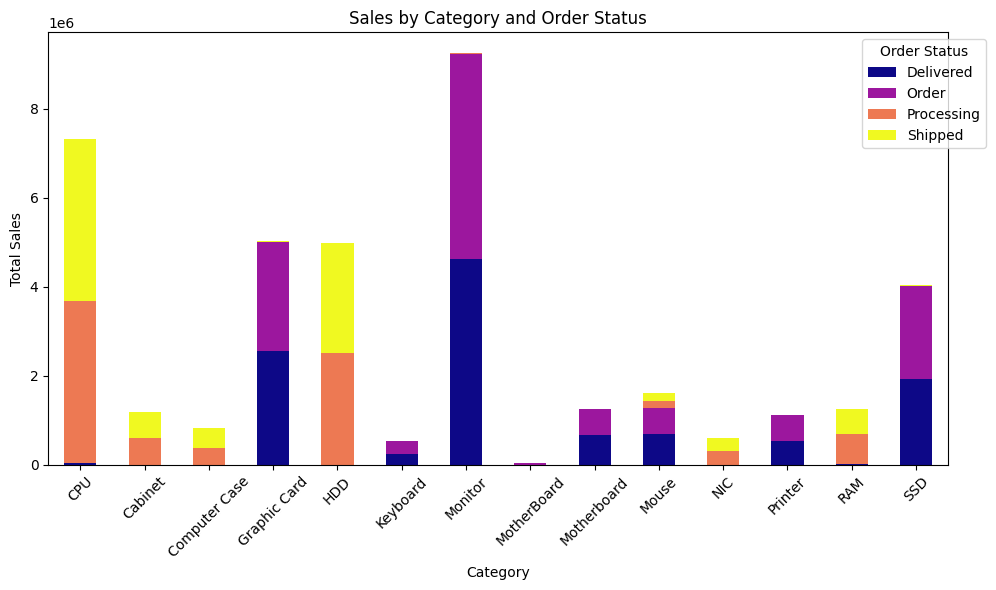

In [53]:
# Stacked Bar Plot — Total Sales by Category and Order Status
status_sales = df.groupby(
    ['Category', 'Status'], observed=False
)['Total_Sales'].sum().unstack()

status_sales.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='plasma'
)

plt.title("Sales by Category and Order Status")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.legend(title="Order Status", bbox_to_anchor=(1.05,1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Monthly Sales Trend (Line Chart)**

The line chart clearly shows fluctuations in sales across different months. Some months experience higher sales peaks, indicating seasonal demand, while others show a decline. This visualization helps identify sales growth patterns and supports forecasting future sales trends.

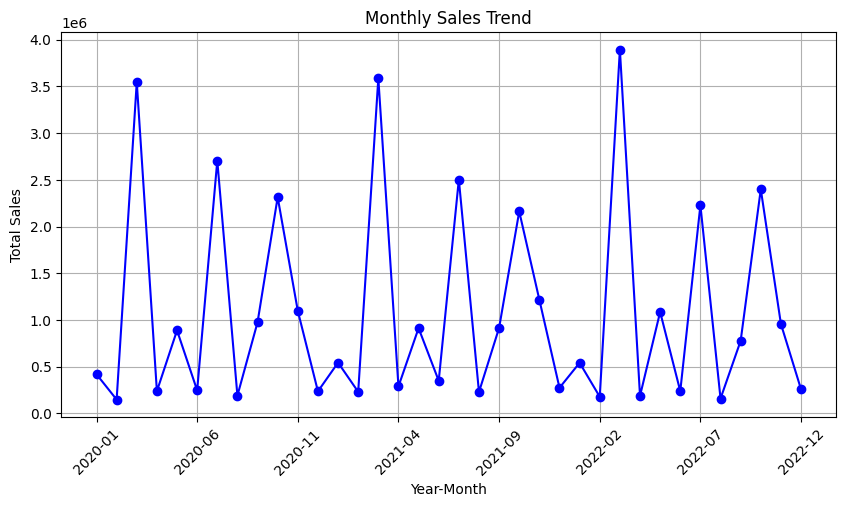

In [54]:
# Line Chart — Monthly Sales Trend
monthly_sales = df.groupby('Year_Month')['Total_Sales'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o', color='blue')
plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**Top 10 Products by Profit (Bar Chart)**

The bar chart of the top 10 products by profit reveals that a small number of products generate the highest profit. This indicates that profitability is concentrated among key products. Businesses can focus on promoting these high-profit products to maximize revenue.

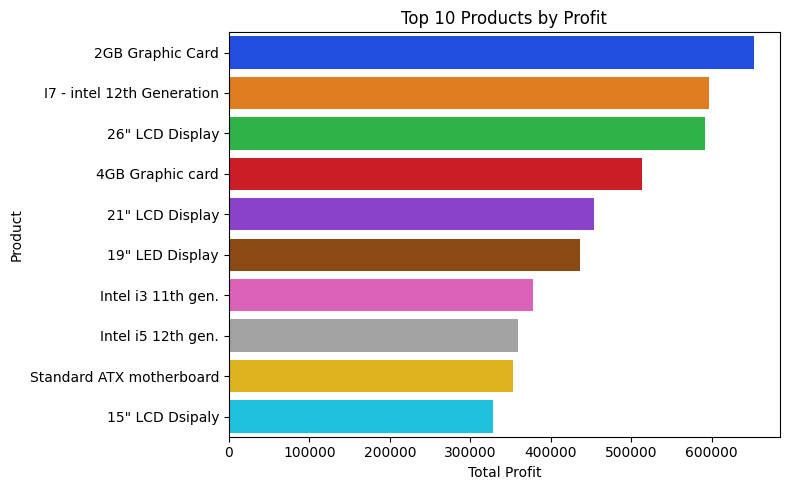

In [55]:
# Bar Chart — Top 10 Products by Profit
top_products = (
    df.groupby('Product')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(8,5))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,
    palette='bright',
    legend=False
)

plt.title("Top 10 Products by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Product")
plt.tight_layout()
plt.show()



**Sales Contribution by Category (Pie Chart)**

The pie chart shows the percentage contribution of each category to total sales. A few major categories dominate the overall sales, while the remaining categories contribute relatively less and are grouped as “Others.” This insight helps in understanding category-wise sales dependency.

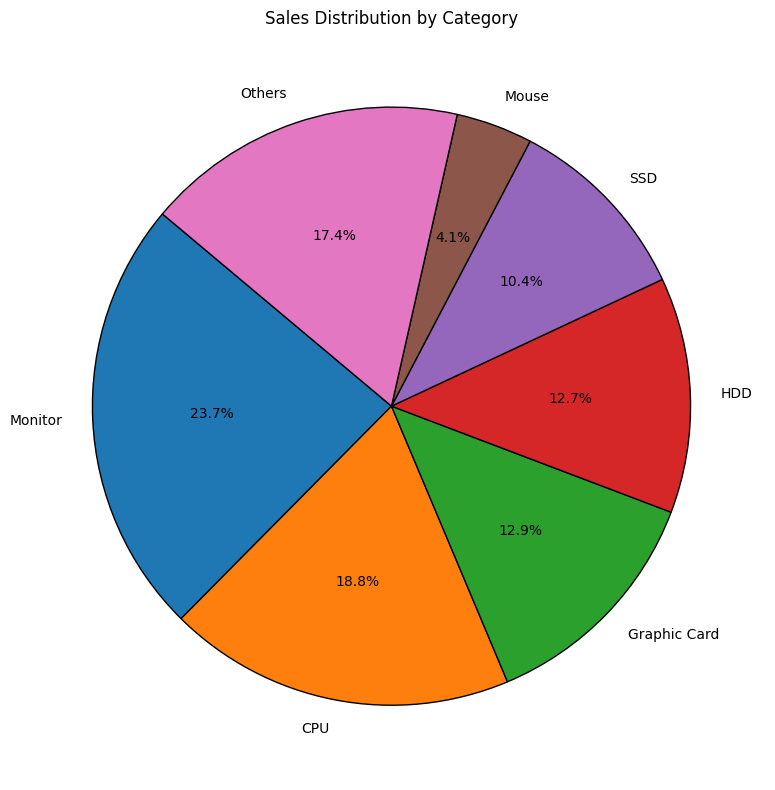

In [56]:
# Pie Chart — Sales Contribution by Category
category_sales = df.groupby(
    'Category',
    observed=False
)['Total_Sales'].sum().sort_values(ascending=False)

top_n = 6
top_categories = category_sales[:top_n]
others = category_sales[top_n:].sum()

category_sales_clean = top_categories.copy()
category_sales_clean['Others'] = others

import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.pie(
    category_sales_clean,
    labels=category_sales_clean.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'black'}
)

plt.title("Sales Distribution by Category")
plt.tight_layout()
plt.show()


**Distribution of Total Sales (Histogram)**

The histogram shows that most sales values fall within a specific range, while a few high-value sales act as outliers. This indicates that the majority of transactions are of moderate value, with occasional large purchases.

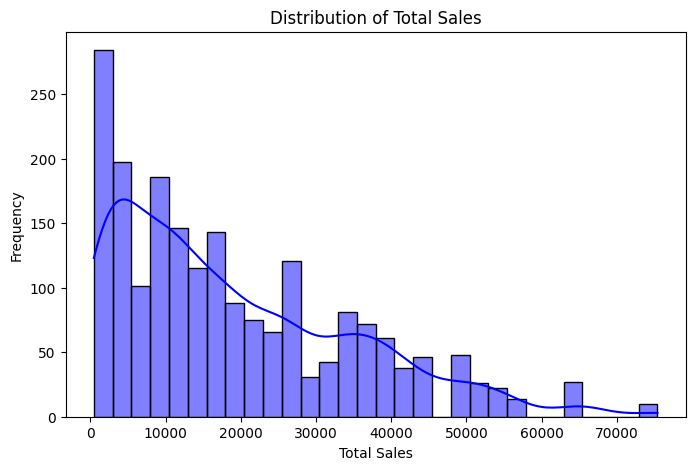

In [57]:
# Histogram — Distribution of Total Sales
plt.figure(figsize=(8,5))
sns.histplot(df['Total_Sales'], bins=30, kde=True, color='blue')
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()

**Profit Distribution by Category (Box Plot)**

The box plot highlights variations in profit across different categories. Some categories show higher median profit and wider spread, indicating higher profitability and variability. Other categories show lower or more consistent profit margins.

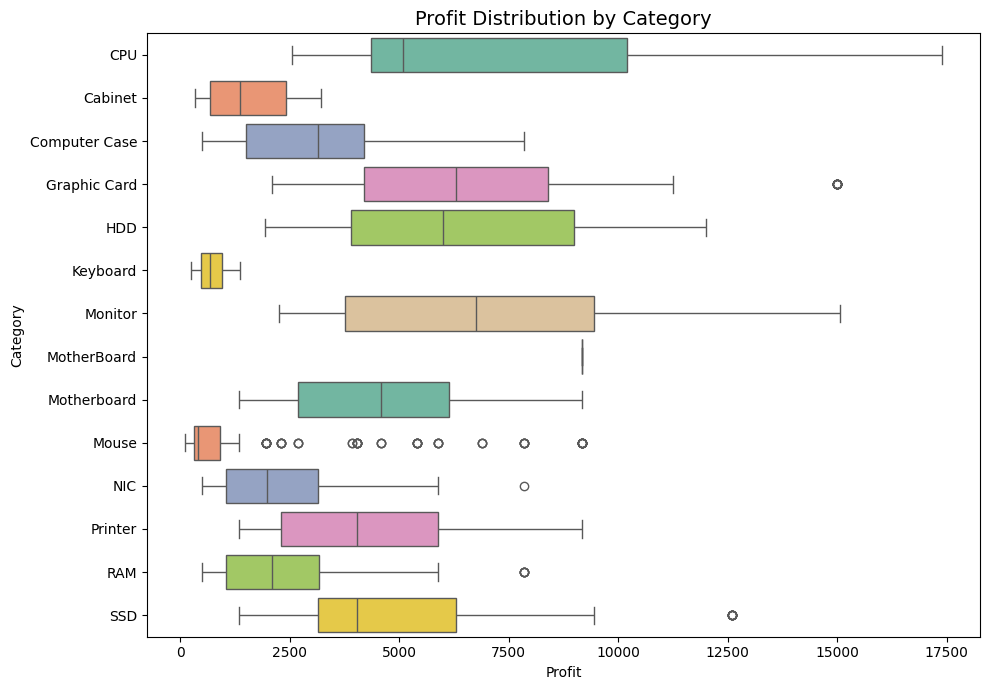

In [59]:
# Box Plot — Profit Distribution by Category
plt.figure(figsize=(10,7))

sns.boxplot(
    y='Category',
    x='Profit',
    data=df,
    hue='Category',
    palette='Set2',
    legend=False
)

plt.title("Profit Distribution by Category", fontsize=14)
plt.xlabel("Profit")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


**Quantity vs Total Sales (Scatter Plot)**

The scatter plot shows a positive relationship between quantity and total sales, meaning higher quantities generally result in higher sales. However, the spread of points indicates that price differences also affect total sales, not just quantity.

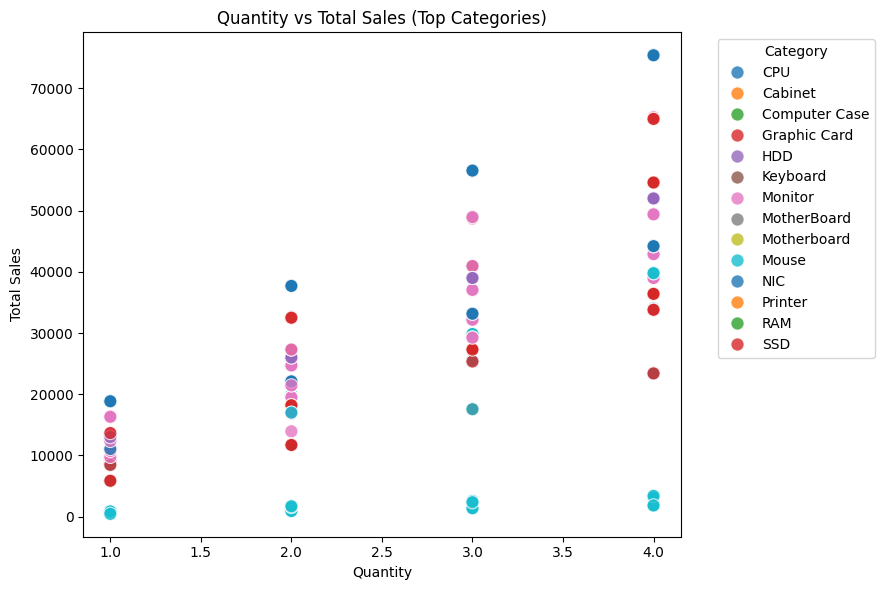

In [60]:
# Scatter Plot — Quantity vs Total Sales
top_categories = (
    df.groupby('Category', observed=False)['Total_Sales']
      .sum()
      .sort_values(ascending=False)
      .head(6)
      .index
)

df_top = df[df['Category'].isin(top_categories)]

plt.figure(figsize=(9,6))

sns.scatterplot(
    x='Quantity',
    y='Total_Sales',
    data=df_top,
    hue='Category',
    palette='tab10',
    alpha=0.8,
    s=90
)

plt.title("Quantity vs Total Sales (Top Categories)")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.legend(title="Category", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()


**Correlation Analysis (Heatmap)**

The correlation heatmap shows a strong positive correlation between Total Sales and Profit, indicating that higher sales usually lead to higher profit. Quantity also shows a positive relationship with sales, while Total Cost is closely related to both sales and profit.

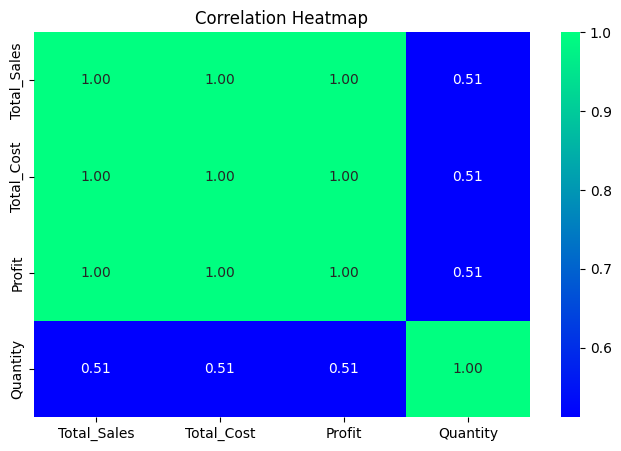

In [61]:
# HEATMAP — Correlation Matrix
corr_matrix = df[['Total_Sales', 'Total_Cost', 'Profit', 'Quantity']].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, cmap='winter', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Sales and Profit Comparison by Category (Subplots)**

The side-by-side bar charts allow easy comparison of total sales and total profit by category. Some categories perform well in sales but generate relatively lower profit, while others show strong profitability. This helps identify high-margin categories.

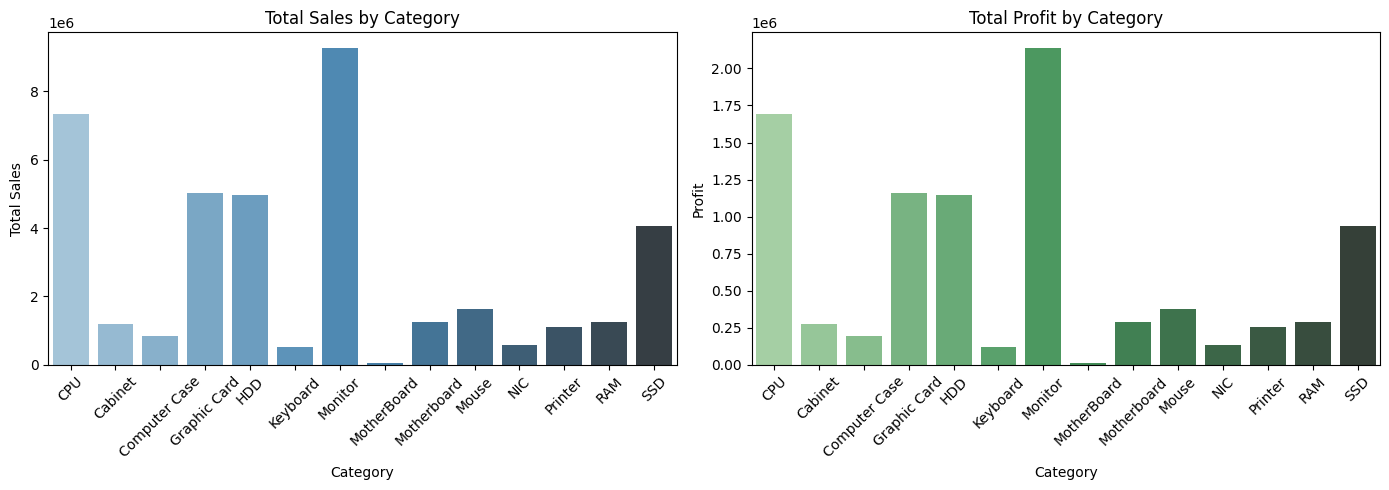

In [62]:
# SUBPLOTS — Sales & Profit Comparison
sales_by_category = df.groupby(
    'Category',
    observed=False
)['Total_Sales'].sum()

profit_by_category = df.groupby(
    'Category',
    observed=False
)['Profit'].sum()


fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Total Sales
sns.barplot(
    x=sales_by_category.index,
    y=sales_by_category.values,
    hue=sales_by_category.index,
    palette='Blues_d',
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Total Sales by Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Total Sales")
axes[0].tick_params(axis='x', rotation=45)

# Total Profit
sns.barplot(
    x=profit_by_category.index,
    y=profit_by_category.values,
    hue=profit_by_category.index,
    palette='Greens_d',
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Total Profit by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Profit")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Pareto Chart – Top Products Contribution (80/20 Rule)**

The Pareto chart illustrates the contribution of top products to overall sales. The bar chart represents the total sales of the highest-performing products, while the red line shows the cumulative percentage of total sales contributed by these products.

The visualization indicates that a small number of products contribute a large portion of total sales, confirming the Pareto Principle (80/20 rule). This means that focusing on a few key products can significantly influence overall business revenue.

This insight helps businesses identify high-impact products, improve inventory planning, and prioritize marketing efforts on products that generate the most sales.

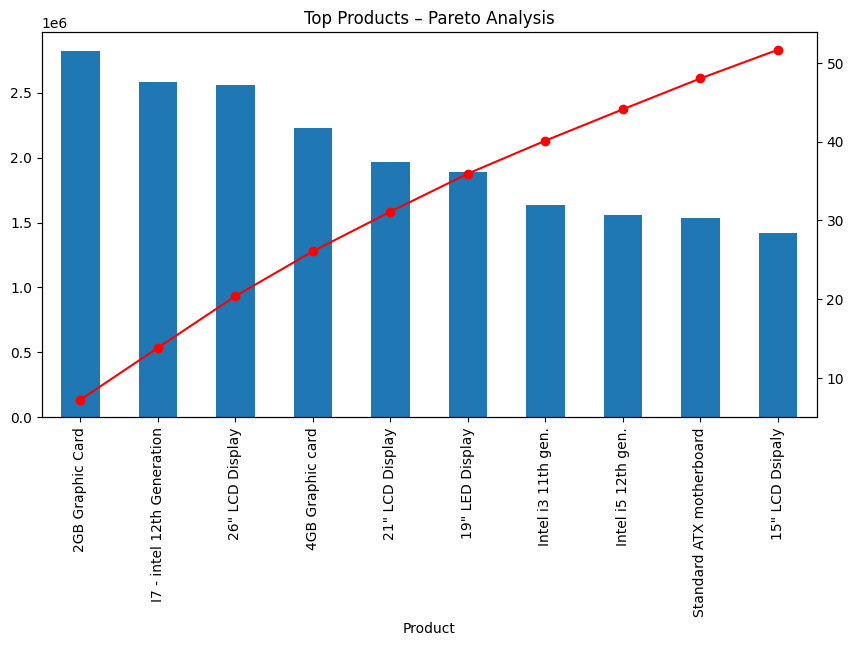

In [65]:
# Pareto Chart — Top Products Contribution (80/20 Rule)
product_sales = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)
cum_percent = product_sales.cumsum() / product_sales.sum() * 100

plt.figure(figsize=(10,5))
product_sales.head(10).plot(kind='bar')
plt.twinx().plot(cum_percent.head(10), color='red', marker='o')
plt.title("Top Products – Pareto Analysis")
plt.show()


**Interactive Monthly Sales Trend (Plotly)**

The interactive chart highlights monthly sales trends and seasonal patterns, making it easier to identify peak and low-performing months for better forecasting and planning.

In [63]:
# PLOTLY INTERACTIVE CHART
import plotly.express as px

fig = px.line(
    df.groupby('Year_Month')['Total_Sales'].sum().reset_index(),
    x='Year_Month',
    y='Total_Sales',
    title='Interactive Monthly Sales Trend'
)
fig.show()

**Insight Generation and Report**

This project analyzed e-commerce sales data to identify sales trends, category and product performance, and profitability patterns. The analysis revealed seasonal variations in sales, concentration of revenue among a few products and categories, and a strong positive relationship between sales and profit. These insights support data-driven decision-making and business planning.

# **Logic, Methods, and Interpretation of Results**

**Logic**

The logic of this analysis follows a structured approach to understand e-commerce sales performance. The process begins with data collection and cleaning to ensure data accuracy. Exploratory Data Analysis (EDA) is then used to identify trends, patterns, and relationships within the data. Finally, insights from visualizations and statistical analysis are interpreted to support meaningful conclusions and recommendations.

**Methods**

*   The dataset was downloaded from Google Drive and loaded into Python using the pandas library.
*   Data cleaning was performed by checking for missing values, correcting data types, and converting date columns into datetime format.
*   Exploratory Data Analysis (EDA) was conducted using summary statistics to understand the distribution and structure of the data.
*   Data was aggregated using grouping techniques to analyze sales, profit, and quantity by category, product, order status, and time.
*   Multiple visualizations such as bar charts, line charts, Pareto charts, histograms, box plots, scatter plots, pie charts, and heatmaps were created to identify patterns and relationships.
*   Correlation analysis was used to examine relationships between numerical variables such as total sales, profit, cost, and quantity.
*   Insights were generated by interpreting the results of statistical analysis and visualizations.

**Interpretation of Results**

The analysis provides valuable insights into the overall performance of the e-commerce business. Monthly sales trends show noticeable fluctuations, indicating seasonal variations in customer demand. Certain months consistently record higher sales, suggesting peak periods for business activity.

Category-level analysis reveals that a small number of categories contribute most of the total sales and profit. However, some high-sales categories show relatively lower profit margins, highlighting possible pricing or cost inefficiencies.

Product-level analysis, including Pareto analysis, indicates that a few top-performing products generate a significant portion of total sales. These products play a critical role in driving revenue and should be prioritized in business strategies.

Correlation analysis shows a strong positive relationship between total sales and profit, confirming that increased sales generally lead to higher profitability. Quantity sold also has a positive impact on sales, though pricing differences influence revenue levels.

The presence of a few high-value transactions suggests that outliers have a notable impact on total sales. Overall, the results highlight key sales trends, revenue drivers, and relationships that support data-driven decision-making.

# **Significant Patterns, Correlations, and Anomalies**

**Significant Patterns**

*   **Seasonality in Sales**: Monthly sales data shows recurring peaks and dips, indicating strong seasonal buying behavior, likely driven by festivals, promotions, or discount periods.
*   **Revenue Concentration**: A small subset of products and categories contributes a disproportionately large share of total sales, confirming the Pareto (80/20) principle.
*   **Category Performance Variation**: Some categories consistently generate high sales, while others remain stable but low-performing across all months.
*   **Growth Trend Over Time**: Despite short-term fluctuations, the overall sales trend shows gradual growth, suggesting increasing customer engagement and business expansion.
*   **Mixed Profitability Across Categories**: High sales volume does not always correspond to high profit, revealing differences in pricing strategies, cost structures, and discounting.
*   **Customer Purchase Behavior**: Most orders fall within a moderate sales range, with occasional high-value purchases indicating the presence of premium or bulk-buying customers.

**Key Correlations**

*   **Total Sales vs Profit**: A strong positive correlation exists between total sales and profit, indicating that higher sales generally lead to higher profitability.
*   **Quantity vs Total Sales**: There is a moderate to strong positive correlation, showing that an increase in the number of items sold typically results in higher revenue.
*   **Quantity vs Profit**: The correlation is weaker compared to sales, suggesting that higher quantities do not always translate into higher profit due to discounts, cost variations, or low-margin products.
*   **Total Cost vs Profit**: A noticeable correlation highlights the impact of cost management on profitability; higher costs can significantly reduce net profit even when sales are high.
*   **Category-Level Correlation Patterns**: Correlation strength varies across categories, indicating that different product types respond differently to pricing, quantity, and cost dynamics.

**Notable Anomalies**

*   **High-Value Order Outliers**: A small number of orders show exceptionally high total sales compared to the majority. These outliers likely represent bulk purchases or premium-priced products.
*   **High Sales but Low Profit Products**: Certain products and categories generate high revenue but contribute relatively low profit, indicating heavy discounting, high costs, or inefficient pricing strategies.
*   **Sudden Monthly Sales Drops**: Despite an overall upward sales trend, some months exhibit unexpected declines in sales, suggesting potential supply chain disruptions, reduced promotions, or external market influences.
*   **Profit Variability Within Categories**: Some categories display large fluctuations in profit values, while others remain stable, indicating inconsistent demand or cost structure volatility.
*   **Low-Quantity, High-Sales Orders**: A few orders achieve high sales with low quantities, highlighting the presence of high-priced or premium items.

# **Overall Summary of Findings**

The e-commerce data analysis reveals clear patterns in customer purchasing behavior, sales performance, and profitability across categories, brands, and time periods. Sales are concentrated within a few key categories and products, confirming that a small segment of offerings drives a significant portion of total revenue. Monthly sales trends indicate noticeable seasonality, with peak periods contributing disproportionately to overall performance.

A strong positive correlation exists between Total Sales and Profit, indicating that revenue growth generally leads to higher profitability. However, this relationship weakens in cases where high costs or discounts reduce margins, highlighting inefficiencies in pricing or cost management. Quantity sold is positively related to sales value, but not always to profit, suggesting that volume alone does not guarantee profitability.

While most transactions fall within a moderate sales range, several high-value outliers significantly impact total revenue. Additionally, some products generate high sales but low or negative profit, pointing to potential margin leakage. Profit variability across categories and brands suggests differences in demand stability, cost structure, and pricing effectiveness.

**Recommendations & Next Steps**

**Business Recommendations**

*   **Focus on High-Profit Products**: Prioritize inventory, marketing, and promotions for top-performing products and brands that consistently deliver high profit margins.
*   **Optimize Pricing Strategies**: Review products with high sales but low profit to reassess pricing, discounting, and cost structures.
*   **Improve Cost Management**: Tight control over procurement and logistics costs can significantly enhance profitability, especially for high-volume categories.
*   **Leverage Seasonal Trends**: Align marketing campaigns, inventory planning, and staffing with peak sales months to maximize revenue during high-demand periods.
*   **Reduce Loss-Making Orders**: Investigate negative-profit orders to identify causes such as excessive discounts, returns, or high operational costs.

**Analytical Next Steps**

*   **Customer Segmentation Analysis**: Segment customers based on purchase behavior to enable targeted marketing and personalized promotions.
*   **Product-Level Profitability Tracking**: Monitor profit margins at a granular product level to detect early signs of declining performance.
*   **Predictive Sales Forecasting**: Apply time-series forecasting models to anticipate future demand and optimize inventory levels.
*   **Promotion Impact Analysis**: Evaluate the effectiveness of discounts and campaigns on both sales volume and profitability.


